## 0. Download and Process the Dataset

In [1]:
!pip install opendatasets --upgrade --quiet

In [2]:
import os
import random
import pandas as pd
import numpy as np
import opendatasets as od
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset_url = "https://www.kaggle.com/competitions/new-york-city-taxi-fare-prediction/data"

od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: krasivachev
Your Kaggle Key: ··········


100%|██████████| 1.56G/1.56G [00:18<00:00, 91.0MB/s]



Extracting archive ./new-york-city-taxi-fare-prediction/new-york-city-taxi-fare-prediction.zip to ./new-york-city-taxi-fare-prediction


In [4]:
data_dir = "/content/new-york-city-taxi-fare-prediction"
train_data_path = "/content/new-york-city-taxi-fare-prediction/train.csv"
test_data_path = "/content/new-york-city-taxi-fare-prediction/test.csv"

In [5]:
sample_fraction = 0.01

In [6]:
selected_cols = "fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count".split(",")    # key is removed
selected_cols

['fare_amount',
 'pickup_datetime',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count']

In [7]:
dtypes = {
 "fare_amount": "float64",
 "pickup_datetime": "float64",
 "pickup_longitude": "float64",
 "pickup_latitude": "float64",
 "dropoff_longitude": "float64",
 "dropoff_latitude": "float64",
 "passenger_count": "uint8"
}

def skip_row(row_idx):
    if row_idx == 0:
        return False
    return random.random() > sample_fraction

In [8]:
df = pd.read_csv(train_data_path,
                 usecols = selected_cols,
                 dtype = dtypes,
                 parse_dates = ["pickup_datetime"],
                 skiprows = skip_row, )

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555305 entries, 0 to 555304
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        555305 non-null  float64            
 1   pickup_datetime    555305 non-null  datetime64[ns, UTC]
 2   pickup_longitude   555305 non-null  float64            
 3   pickup_latitude    555305 non-null  float64            
 4   dropoff_longitude  555297 non-null  float64            
 5   dropoff_latitude   555297 non-null  float64            
 6   passenger_count    555305 non-null  uint8              
dtypes: datetime64[ns, UTC](1), float64(5), uint8(1)
memory usage: 25.9 MB


In [10]:
df.head(10)

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.7,2011-02-22 11:09:16+00:00,-73.968881,40.764533,-73.985311,40.748956,1
1,9.0,2013-01-09 14:42:00+00:00,-73.946852,40.775802,-73.964340,40.760703,1
2,12.9,2012-06-05 09:16:00+00:00,-73.965315,40.790852,-73.978195,40.766375,6
3,9.5,2013-08-09 21:19:00+00:00,-73.992583,40.730417,-74.005352,40.740247,1
4,21.5,2015-01-30 00:16:06+00:00,-74.001099,40.721497,-73.959435,40.653065,1
5,11.7,2012-06-24 17:33:00+00:00,-73.954497,40.769857,-73.984315,40.746007,1
6,5.7,2011-07-21 15:43:00+00:00,-73.989807,40.741230,-73.993917,40.726492,1
7,9.7,2011-03-09 22:21:25+00:00,-73.977829,40.788979,-73.967935,40.760508,1
8,8.1,2010-01-15 11:11:07+00:00,-73.978916,40.787120,-73.957307,40.783588,1
9,5.3,2009-01-16 05:58:00+00:00,-73.992010,40.755538,-73.997960,40.755995,5


In [11]:
test_df = pd.read_csv(test_data_path, dtype = dtypes, parse_dates = ["pickup_datetime"])

In [12]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9914 entries, 0 to 9913
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   key                9914 non-null   object             
 1   pickup_datetime    9914 non-null   datetime64[ns, UTC]
 2   pickup_longitude   9914 non-null   float64            
 3   pickup_latitude    9914 non-null   float64            
 4   dropoff_longitude  9914 non-null   float64            
 5   dropoff_latitude   9914 non-null   float64            
 6   passenger_count    9914 non-null   uint8              
dtypes: datetime64[ns, UTC](1), float64(4), object(1), uint8(1)
memory usage: 474.5+ KB


In [13]:
test_df.head(10)

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966046,40.789775,-73.988565,40.744427,1
5,2012-12-01 21:12:12.0000005,2012-12-01 21:12:12+00:00,-73.960983,40.765547,-73.979177,40.740053,1
6,2011-10-06 12:10:20.0000001,2011-10-06 12:10:20+00:00,-73.949013,40.773204,-73.959622,40.770893,1
7,2011-10-06 12:10:20.0000003,2011-10-06 12:10:20+00:00,-73.777282,40.646636,-73.985083,40.759368,1
8,2011-10-06 12:10:20.0000002,2011-10-06 12:10:20+00:00,-74.014099,40.709638,-73.995106,40.741365,1
9,2014-02-18 15:22:20.0000002,2014-02-18 15:22:20+00:00,-73.969582,40.765519,-73.980686,40.770725,1


In [14]:
df.loc[df.isna().any(axis = "columns")].count()

,0
fare_amount,8
pickup_datetime,8
pickup_longitude,8
pickup_latitude,8
dropoff_longitude,0
dropoff_latitude,0
passenger_count,8


In [15]:
df.dropna(inplace = True)

In [16]:
test_df.loc[test_df.isna().any(axis = "columns")].count()

,0
key,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


## 1. Analyze the Dataset

In [17]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,555297.000000,555297.000000,555297.000000,555297.000000,555297.000000,555297.000000
mean,11.329297,-72.498620,39.893583,-72.490373,39.902629,1.686281
std,9.799125,14.080461,11.779361,13.170965,9.746037,1.337537
min,-60.000000,-3370.710497,-2920.439457,-3036.573595,-2861.699833,0.000000
25%,6.000000,-73.992075,40.734972,-73.991394,40.734043,1.000000
50%,8.500000,-73.981792,40.752716,-73.980139,40.753265,1.000000
75%,12.500000,-73.967022,40.767152,-73.963716,40.768167,2.000000
max,430.000000,2160.097697,3361.254635,2462.165283,3306.705933,208.000000


In [18]:
df["pickup_datetime"].min(), df["pickup_datetime"].max()

(Timestamp('2009-01-01 00:02:52+0000', tz='UTC'),
 Timestamp('2015-06-30 23:59:26+0000', tz='UTC'))

In [19]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974722,40.751041,-73.973657,40.751743,1.671273
std,0.042774,0.033541,0.039072,0.035435,1.278747
min,-74.252193,40.573143,-74.263242,40.568973,1.000000
25%,-73.992501,40.736125,-73.991247,40.735254,1.000000
50%,-73.982326,40.753051,-73.980015,40.754065,1.000000
75%,-73.968013,40.767113,-73.964059,40.768757,2.000000
max,-72.986532,41.709555,-72.990963,41.696683,6.000000


In [20]:
test_df["pickup_datetime"].min(), test_df["pickup_datetime"].max()

(Timestamp('2009-01-01 11:04:24+0000', tz='UTC'),
 Timestamp('2015-06-30 20:03:50+0000', tz='UTC'))

## 2. Train and Test Dataset

In [21]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size = 0.2, random_state = 42)
len(train_df), len(val_df), len(test_df)

(444237, 111060, 9914)

In [22]:
train_df = train_df.dropna()
val_df = val_df.dropna()

In [23]:
train_df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [24]:
input_cols = ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "passenger_count"]
target_col = "fare_amount"

In [25]:
train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

In [26]:
train_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
243803,-73.989312,40.723095,-73.991157,40.666475,5
300467,-73.996097,40.726661,-73.988436,40.722784,1
145325,-73.988860,40.744980,-73.980900,40.782000,5
344355,-74.006787,40.711179,-73.962144,40.716062,1
165052,-73.982360,40.767260,-73.974332,40.762650,1
...,...,...,...,...,...
110270,-73.975792,40.757287,-73.969620,40.762155,1
259184,-74.003700,40.753342,-73.984603,40.754172,2
365845,-73.994805,40.731632,-73.980767,40.751157,1
131934,-73.992261,40.753978,-74.004823,40.741717,1


In [27]:
train_targets

,fare_amount
243803,20.0
300467,6.0
145325,18.0
344355,17.0
165052,5.3
...,...
110270,3.7
259184,8.0
365845,12.0
131934,6.5


In [28]:
val_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
462211,-73.962457,40.778895,-73.977155,40.758312,2
203081,-73.952795,40.783008,-73.961948,40.776265,1
499187,-73.970508,40.752288,-73.980951,40.741260,1
499055,0.000000,0.000000,0.000000,0.000000,2
397300,-73.996520,40.753062,-73.975040,40.656155,5
...,...,...,...,...,...
75318,-74.002403,40.739928,-73.988258,40.759413,1
278711,-73.978432,40.754478,-73.984596,40.746811,1
43362,-73.990077,40.756933,-73.988899,40.773557,1
374350,-73.984787,40.757648,-73.872948,40.774380,2


In [29]:
val_targets

,fare_amount
462211,8.10
203081,5.30
499187,4.50
499055,4.50
397300,30.33
...,...
75318,6.10
278711,7.00
43362,8.00
374350,44.33


In [30]:
test_inputs = test_df[input_cols]

In [31]:
test_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,-73.973320,40.763805,-73.981430,40.743835,1
1,-73.986862,40.719383,-73.998886,40.739201,1
2,-73.982524,40.751260,-73.979654,40.746139,1
3,-73.981160,40.767807,-73.990448,40.751635,1
4,-73.966046,40.789775,-73.988565,40.744427,1
...,...,...,...,...,...
9909,-73.968124,40.796997,-73.955643,40.780388,6
9910,-73.945511,40.803600,-73.960213,40.776371,6
9911,-73.991600,40.726608,-73.789742,40.647011,6
9912,-73.985573,40.735432,-73.939178,40.801731,6


## 3. Base Model

### 3.1 Mean Model

In [32]:
class MeanRegressor:
    def fit(self, inputs, targets):
        self.mean = targets.mean()

    def predict(self, inputs):
        return np.full(inputs.shape[0], self.mean)

In [33]:
mean_model = MeanRegressor()

mean_model.fit(train_inputs, train_targets)
mean_model.mean

np.float64(11.318642346315146)

In [34]:
train_preds = mean_model.predict(train_inputs)
val_preds = mean_model.predict(val_inputs)

In [35]:
train_preds, val_preds

(array([11.31864235, 11.31864235, 11.31864235, ..., 11.31864235,
        11.31864235, 11.31864235]),
 array([11.31864235, 11.31864235, 11.31864235, ..., 11.31864235,
        11.31864235, 11.31864235]))

In [36]:
train_targets

,fare_amount
243803,20.0
300467,6.0
145325,18.0
344355,17.0
165052,5.3
...,...
110270,3.7
259184,8.0
365845,12.0
131934,6.5


In [37]:
val_targets

,fare_amount
462211,8.10
203081,5.30
499187,4.50
499055,4.50
397300,30.33
...,...
75318,6.10
278711,7.00
43362,8.00
374350,44.33


In [38]:
from sklearn.metrics import mean_squared_error

def rmse(targets, preds):
    return np.sqrt(mean_squared_error(targets, preds))

In [39]:
train_rmse = rmse(train_targets, train_preds)
train_rmse

np.float64(9.773430760690182)

In [40]:
val_rmse = rmse(val_targets, val_preds)
val_rmse

np.float64(9.90121873273038)

### 3.2 Linear Regression Model

In [41]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(train_inputs, train_targets)
train_preds = linear_model.predict(train_inputs)
train_preds

array([11.64298999, 11.23609785, 11.64288068, ..., 11.23609783,
       11.23594027, 11.2359138 ])

In [42]:
linear_train_rmse = rmse(train_targets, train_preds)
linear_train_rmse

np.float64(9.771972517871621)

In [43]:
val_preds = linear_model.predict(val_inputs)
val_preds

array([11.3377506 , 11.23610364, 11.23609607, ..., 11.23598213,
       11.33822594, 11.23608843])

In [44]:
rmse(val_targets, val_preds)

np.float64(9.899788731572214)

### 3.3 Automate Kaggle Submission

In [45]:
target_col

'fare_amount'

In [46]:
submission_file_path = "/content/new-york-city-taxi-fare-prediction/sample_submission.csv"

def predict_and_submit(model, test_inputs, file_name):
    test_preds = model.predict(test_inputs)
    sub_df = pd.read_csv(submission_file_path)
    sub_df["fare_amount"] = test_preds
    sub_dir = "submission/" + file_name
    sub_df.to_csv(sub_dir, index = None)
    return sub_df

In [47]:
linear_sub_df = predict_and_submit(linear_model, test_inputs, "simple_linear_model.csv")

## 4. Feature Engineering

### 4.1 Divide Data into Separate Columns

In [48]:
def add_date(df, col):
    df[col + "_year"] = df[col].dt.year
    df[col + "_month"] = df[col].dt.month
    df[col + "_day"] = df[col].dt.day
    df[col + "_weekday"] = df[col].dt.weekday
    df[col + "_hour"] = df[col].dt.hour

In [49]:
add_date(train_df, "pickup_datetime")
add_date(val_df, "pickup_datetime")
add_date(test_df, "pickup_datetime")

In [50]:
pd.set_option("display.max_columns", None)
train_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour
243803,20.0,2014-01-29 20:58:00+00:00,-73.989312,40.723095,-73.991157,40.666475,5,2014,1,29,2,20
300467,6.0,2014-06-14 02:18:33+00:00,-73.996097,40.726661,-73.988436,40.722784,1,2014,6,14,5,2
145325,18.0,2014-04-10 13:51:00+00:00,-73.988860,40.744980,-73.980900,40.782000,5,2014,4,10,3,13
344355,17.0,2013-08-16 23:46:48+00:00,-74.006787,40.711179,-73.962144,40.716062,1,2013,8,16,4,23
165052,5.3,2012-06-06 18:42:00+00:00,-73.982360,40.767260,-73.974332,40.762650,1,2012,6,6,2,18
...,...,...,...,...,...,...,...,...,...,...,...,...
110270,3.7,2012-05-26 20:36:00+00:00,-73.975792,40.757287,-73.969620,40.762155,1,2012,5,26,5,20
259184,8.0,2012-09-07 17:36:00+00:00,-74.003700,40.753342,-73.984603,40.754172,2,2012,9,7,4,17
365845,12.0,2013-05-17 09:44:00+00:00,-73.994805,40.731632,-73.980767,40.751157,1,2013,5,17,4,9
131934,6.5,2011-01-10 10:36:04+00:00,-73.992261,40.753978,-74.004823,40.741717,1,2011,1,10,0,10


In [51]:
train_df.drop("pickup_datetime", axis = 1, inplace = True)
val_df.drop("pickup_datetime", axis = 1, inplace = True)
test_df.drop("pickup_datetime", axis = 1, inplace = True)

### 4.2 Trip Distanance

In [52]:
def haversine_np(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points on the earth
    (specified in degrees).
    """
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

In [53]:
def add_trip_distance(df):
    df["trip_distance"] = haversine_np(df["pickup_longitude"], df["pickup_latitude"],
                                       df["dropoff_longitude"], df["dropoff_latitude"])

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 555297 entries, 0 to 555304
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        555297 non-null  float64            
 1   pickup_datetime    555297 non-null  datetime64[ns, UTC]
 2   pickup_longitude   555297 non-null  float64            
 3   pickup_latitude    555297 non-null  float64            
 4   dropoff_longitude  555297 non-null  float64            
 5   dropoff_latitude   555297 non-null  float64            
 6   passenger_count    555297 non-null  uint8              
dtypes: datetime64[ns, UTC](1), float64(5), uint8(1)
memory usage: 30.2 MB


In [55]:
add_trip_distance(train_df)
add_trip_distance(val_df)
add_trip_distance(test_df)

### 4.3 Distance to Famous NY Landmarks

In [56]:
# The most famous landmarks of NY City

jfk_airport_lonlat = -73.7781, 40.6413          # JFL Airport
lga_airport_lonlat = -73.8740, 40.7769          # LGA Airport
ewr_airport_lonlat = -74.1745, 40.6895          # EWR Airport
wtc_lonlat = -73.0099, 40.7126                  # World Trade Centre
central_park_lonlat = -73.9683, 40.7851         # Central Park
statue_liberty_lonlat = -74.0445, 40.6892       # Statue of Liberty
times_square_lonlat = -73.9851, 40.7589         # Times Square
empire_state_lonlat = -73.9854, 40.7488         # Empire State Building
n11_memorial_lonlat = -74.0139, 40.7114         # 9/11 Memorial
brooklyn_bridge_lonlat = -73.9970, 40.7060      # Brooklyn Bridge
met_museum_lonlat = -73.9634, 40.7794           # Metropolitan Museum of Art
rockefeller_lonlat = -73.9788, 40.7587          # Rockefeller Center
high_line_lonlat = -74.0076, 40.7527            # High Line
one_world_lonlat = -74.0134, 40.7128            # One World Observatory

chrysler_lonlat = -73.9754, 40.7516             # Chrysler Building
flatiron_lonlat = -73.9895, 40.7411             # Flatiron Building
grand_central_lonlat = -73.9772, 40.7527        # Grand Central Terminal
ellis_island_lonlat = -74.0396, 40.6995         # Ellis Island
nypl_main_lonlat = -73.9819, 40.7532            # NY Public Library (Main)
bk_heights_pr_lonlat = -73.9980, 40.6969        # Brooklyn Heights Promenade
st_patricks_lonlat = -73.9750, 40.7585          # St. Patrick's Cathedral
guggenheim_lonlat = -73.9590, 40.7830           # Guggenheim Museum
amnh_lonlat = -73.9730, 40.7813                 # American Museum of Natural History
lincoln_center_lonlat = -73.9835, 40.7725       # Lincoln Center for the Performing Arts

In [57]:
def add_landmark_dropoff_distance(df, landmark_name, landmark_lonlat):
    lon, lat = landmark_lonlat
    # df[dropoff_longitude] and df["dropoff_langitude"] is the location of the landmark
    df[landmark_name + "_drop_distance"] = haversine_np(lon, lat, df["dropoff_longitude"], df["dropoff_latitude"])

In [58]:
landmarks = [
    ("jfk", jfk_airport_lonlat),
    ("lga", lga_airport_lonlat),
    ("ewr", ewr_airport_lonlat),
    ("wtc", wtc_lonlat),
    ("cp", central_park_lonlat),
    ("sl", statue_liberty_lonlat),
    ("ts", times_square_lonlat),
    ("esb", empire_state_lonlat),
    ("911", n11_memorial_lonlat),
    ("bb", brooklyn_bridge_lonlat),
    ("mm", met_museum_lonlat),
    ("rc", rockefeller_lonlat),
    ("hl", high_line_lonlat),
    ("owo", one_world_lonlat),
    ("cb", chrysler_lonlat),
    ("fb", flatiron_lonlat),
    ("gct", grand_central_lonlat),
    ("ei", ellis_island_lonlat),
    ("nypl", nypl_main_lonlat),
    ("bhp", bk_heights_pr_lonlat),
    ("spc", st_patricks_lonlat),
    ("gg", guggenheim_lonlat),
    ("amnh", amnh_lonlat),
    ("lc", lincoln_center_lonlat)
]

In [59]:
def add_landmarks(df_temp, landmarks):
    landmarks = landmarks

    for name, lonlat in landmarks:
        add_landmark_dropoff_distance(df_temp, name, lonlat)

In [60]:
add_landmarks(train_df, landmarks)
add_landmarks(val_df, landmarks)
add_landmarks(test_df, landmarks)

In [61]:
train_df.tail(10)

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,wtc_drop_distance,cp_drop_distance,sl_drop_distance,ts_drop_distance,esb_drop_distance,911_drop_distance,bb_drop_distance,mm_drop_distance,rc_drop_distance,hl_drop_distance,owo_drop_distance,cb_drop_distance,fb_drop_distance,gct_drop_distance,ei_drop_distance,nypl_drop_distance,bhp_drop_distance,spc_drop_distance,gg_drop_distance,amnh_drop_distance,lc_drop_distance
175206,42.0,-73.868923,40.770878,-73.984619,40.681244,1,2013,12,1,6,13,13.933608,17.965844,14.133920,16.026840,82.195156,11.622530,5.122827,8.629627,7.507456,4.161233,2.942156,11.052984,8.621248,8.173065,4.263397,7.856783,6.664200,7.965105,5.057420,7.999397,2.073182,8.623222,11.511596,11.161700,10.141271
87499,21.5,-73.988228,40.748032,-73.928162,40.776321,5,2015,5,30,5,4,5.953417,19.619243,4.558197,22.877161,77.633077,3.515527,13.773124,5.168342,5.706426,10.205606,9.729255,2.984951,4.690179,7.182836,10.066121,4.832676,6.478927,4.891365,12.685387,5.201787,10.605347,4.411534,2.698998,3.813406,4.676244
521437,6.5,-73.974717,40.741887,-73.993637,40.752342,2,2011,3,26,5,8,1.971534,21.955115,10.432622,16.756976,82.954433,4.218812,8.220956,1.023478,0.797345,4.859123,5.157541,3.939212,1.434937,1.176097,4.698688,1.537440,1.296910,1.384260,7.033073,0.992622,6.171946,1.711569,4.483830,3.656776,2.397051
137340,5.5,-73.991310,40.734119,-74.005020,40.739941,5,2015,5,8,4,17,1.323288,22.039402,11.768408,15.336171,83.858181,5.893730,6.546097,2.692792,1.922979,3.258553,3.831662,5.612522,3.036134,1.434424,3.097470,2.810217,1.313077,2.737898,5.355177,2.441259,4.819304,3.261990,6.156306,5.328014,4.046307
54886,4.6,-73.955431,40.776950,-73.945422,40.772625,1,2009,1,10,5,21,0.969764,20.288912,6.029130,21.387912,79.046747,2.372328,12.472114,3.671286,4.281668,8.917969,8.583387,1.689856,3.207238,5.682543,8.772291,3.438814,5.102830,3.472260,11.354160,3.753163,9.508525,2.942961,1.623181,2.512958,3.204519
110270,3.7,-73.975792,40.757287,-73.969620,40.762155,1,2012,5,26,5,20,0.750017,20.992717,8.212476,19.049567,80.995885,2.552184,10.270916,1.352245,1.991713,6.761105,6.652512,1.986560,0.862822,3.365199,6.608279,1.269831,2.876654,1.229247,9.121602,1.434831,7.635141,0.608304,2.482838,2.146422,1.638960
259184,8.0,-74.003700,40.753342,-73.984603,40.754172,2,2012,9,7,4,17,1.610224,21.447958,9.645423,17.533657,82.204861,3.700630,8.807731,0.527063,0.600723,5.355135,5.453963,3.323236,0.701279,1.942789,5.197757,0.825757,1.509997,0.644296,7.639485,0.251874,6.463587,0.940604,3.860771,3.168823,2.038816
365845,12.0,-73.994805,40.731632,-73.980767,40.751157,1,2013,5,17,4,9,2.470758,20.990342,9.430582,17.696777,81.865997,3.915136,8.730149,0.934558,0.469813,5.225249,5.200942,3.462193,0.854414,2.265356,5.071433,0.454483,1.337742,0.345785,7.582926,0.246250,6.201529,0.949479,3.984659,3.412835,2.382873
131934,6.5,-73.992261,40.753978,-74.004823,40.741717,1,2011,1,10,0,10,1.724776,22.123676,11.685202,15.424620,83.847857,5.717627,6.725091,2.530386,1.814803,3.454613,4.023365,5.449028,2.891530,1.242677,3.293582,2.709631,1.291946,2.626340,5.530629,2.313561,5.013338,3.127545,5.993439,5.150032,3.863056
121960,10.5,-73.989497,40.758797,-74.008738,40.742752,1,2012,4,14,5,11,2.408894,22.466495,11.959178,15.164012,84.181148,5.807738,6.669864,2.679526,2.076590,3.511010,4.202004,5.581052,3.081011,1.109616,3.351494,2.973903,1.630108,2.876045,5.464185,2.540265,5.174947,3.336041,6.126125,5.234308,3.929514


### 4.4 Remove Outliers

In [62]:
round((train_df.loc[:, "fare_amount":"passenger_count"]).describe().T, 4)

,count,mean,std,min,25%,50%,75%,max
fare_amount,444237.0,11.3186,9.7734,-52.0000,6.0000,8.5000,12.5000,430.0000
pickup_longitude,444237.0,-72.4849,14.1381,-3370.7105,-73.9921,-73.9818,-73.9670,2160.0977
pickup_latitude,444237.0,39.8807,11.5386,-2920.4395,40.7350,40.7527,40.7672,2944.6490
dropoff_longitude,444237.0,-72.4757,12.9171,-3036.5736,-73.9914,-73.9801,-73.9636,2444.0035
dropoff_latitude,444237.0,39.8898,9.0582,-2861.6998,40.7341,40.7533,40.7682,1248.7138
passenger_count,444237.0,1.6855,1.3439,0.0000,1.0000,1.0000,2.0000,208.0000


In [63]:
def remove_outliers(df):
    return df[
        (df["fare_amount"] >= 2.5) &
        (df["fare_amount"] <= 500.0) &
        (df["pickup_longitude"] >= -75) &
        (df["pickup_longitude"] <= -72) &
        (df["dropoff_longitude"] >= -75) &
        (df["dropoff_longitude"] <= -72) &
        (df["pickup_latitude"] >= 40) &
        (df["pickup_latitude"] <= 42) &
        (df["dropoff_latitude"] >= 40) &
        (df["dropoff_latitude"] <= 42) &
        (df["passenger_count"] >= 1) &
        (df["passenger_count"] <= 6)]

In [64]:
train_df = remove_outliers(train_df)

In [65]:
round((train_df.loc[:, "fare_amount":"passenger_count"]).describe().T, 4)

,count,mean,std,min,25%,50%,75%,max
fare_amount,433179.0,11.3081,9.6851,2.5000,6.0000,8.5000,12.5000,430.0000
pickup_longitude,433179.0,-73.9751,0.0392,-74.9699,-73.9923,-73.9821,-73.9683,-72.6569
pickup_latitude,433179.0,40.7511,0.0300,40.1024,40.7367,40.7535,40.7676,41.6440
dropoff_longitude,433179.0,-73.9743,0.0384,-74.9699,-73.9916,-73.9806,-73.9653,-72.8329
dropoff_latitude,433179.0,40.7515,0.0333,40.1278,40.7357,40.7540,40.7684,41.9291
passenger_count,433179.0,1.6908,1.3062,1.0000,1.0000,1.0000,2.0000,6.0000


In [66]:
train_df

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,wtc_drop_distance,cp_drop_distance,sl_drop_distance,ts_drop_distance,esb_drop_distance,911_drop_distance,bb_drop_distance,mm_drop_distance,rc_drop_distance,hl_drop_distance,owo_drop_distance,cb_drop_distance,fb_drop_distance,gct_drop_distance,ei_drop_distance,nypl_drop_distance,bhp_drop_distance,spc_drop_distance,gg_drop_distance,amnh_drop_distance,lc_drop_distance
243803,20.0,-73.989312,40.723095,-73.991157,40.666475,5,2014,1,29,2,20,6.293824,18.178546,15.745946,15.661755,82.839979,13.322015,5.156255,10.283402,9.161220,5.347473,4.419730,12.764682,10.301233,9.681355,5.478435,9.552192,8.293886,9.653621,5.489356,9.668820,3.429808,10.316449,13.229017,12.851240,11.799676
300467,6.0,-73.996097,40.726661,-73.988436,40.722784,1,2014,6,14,5,2,0.775807,19.904042,11.356638,16.104515,82.424914,7.129307,6.019406,4.023211,2.902311,2.490027,1.999755,6.635094,4.072796,3.695334,2.377363,3.385082,2.037339,3.456416,5.026790,3.424491,2.987055,4.127018,7.135582,6.631161,5.540302
145325,18.0,-73.988860,40.744980,-73.980900,40.782000,5,2014,4,10,3,13,4.168050,23.157558,9.013171,19.271781,82.109011,1.114753,11.620024,2.591211,3.708743,8.322821,8.553594,1.500625,2.595240,3.956128,8.162118,3.409770,4.602299,3.270823,10.415154,3.201510,9.565722,2.658227,1.846087,0.669277,1.078122
344355,17.0,-74.006787,40.711179,-73.962144,40.716062,1,2013,8,16,4,23,3.799253,17.595160,10.038607,18.131638,80.207696,7.689339,7.552933,5.137831,4.131601,4.390103,3.141759,7.039237,4.941350,5.588090,4.332459,4.103882,3.612267,4.264221,6.779336,4.449627,3.695624,4.838568,7.443200,7.306960,6.524320
165052,5.3,-73.982360,40.767260,-73.974332,40.762650,1,2012,6,6,2,18,0.847928,21.334011,8.591087,18.714676,81.395156,2.545879,10.076661,0.997561,1.799109,6.598094,6.578246,2.076303,0.578018,3.010712,6.442671,1.231219,2.713893,1.131743,8.913659,1.228246,7.573439,0.464584,2.603597,2.075513,1.339207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110270,3.7,-73.975792,40.757287,-73.969620,40.762155,1,2012,5,26,5,20,0.750017,20.992717,8.212476,19.049567,80.995885,2.552184,10.270916,1.352245,1.991713,6.761105,6.652512,1.986560,0.862822,3.365199,6.608279,1.269831,2.876654,1.229247,9.121602,1.434831,7.635141,0.608304,2.482838,2.146422,1.638960
259184,8.0,-74.003700,40.753342,-73.984603,40.754172,2,2012,9,7,4,17,1.610224,21.447958,9.645423,17.533657,82.204861,3.700630,8.807731,0.527063,0.600723,5.355135,5.453963,3.323236,0.701279,1.942789,5.197757,0.825757,1.509997,0.644296,7.639485,0.251874,6.463587,0.940604,3.860771,3.168823,2.038816
365845,12.0,-73.994805,40.731632,-73.980767,40.751157,1,2013,5,17,4,9,2.470758,20.990342,9.430582,17.696777,81.865997,3.915136,8.730149,0.934558,0.469813,5.225249,5.200942,3.462193,0.854414,2.265356,5.071433,0.454483,1.337742,0.345785,7.582926,0.246250,6.201529,0.949479,3.984659,3.412835,2.382873
131934,6.5,-73.992261,40.753978,-74.004823,40.741717,1,2011,1,10,0,10,1.724776,22.123676,11.685202,15.424620,83.847857,5.717627,6.725091,2.530386,1.814803,3.454613,4.023365,5.449028,2.891530,1.242677,3.293582,2.709631,1.291946,2.626340,5.530629,2.313561,5.013338,3.127545,5.993439,5.150032,3.863056


In [67]:
round((val_df.loc[:, "fare_amount":"passenger_count"]).describe().T, 4)

,count,mean,std,min,25%,50%,75%,max
fare_amount,111060.0,11.3719,9.9011,-60.0000,6.0000,8.5000,12.5000,400.0000
pickup_longitude,111060.0,-72.5534,13.8472,-1651.0295,-73.9921,-73.9818,-73.9671,2080.4901
pickup_latitude,111060.0,39.9450,12.6969,-1553.0805,40.7349,40.7527,40.7670,3361.2546
dropoff_longitude,111060.0,-72.5492,14.1410,-1688.7962,-73.9915,-73.9803,-73.9640,2462.1653
dropoff_latitude,111060.0,39.9538,12.1128,-1168.5825,40.7339,40.7532,40.7681,3306.7059
passenger_count,111060.0,1.6894,1.3117,0.0000,1.0000,1.0000,2.0000,6.0000


In [68]:
val_df = remove_outliers(val_df)

In [69]:
round((val_df.loc[:, "fare_amount":"passenger_count"]).describe().T, 4)

,count,mean,std,min,25%,50%,75%,max
fare_amount,108380.0,11.3660,9.7916,2.5000,6.0000,8.5000,12.5000,400.0000
pickup_longitude,108380.0,-73.9750,0.0399,-74.6921,-73.9923,-73.9821,-73.9683,-72.0803
pickup_latitude,108380.0,40.7510,0.0304,40.0283,40.7365,40.7534,40.7675,41.7825
dropoff_longitude,108380.0,-73.9744,0.0389,-74.6898,-73.9917,-73.9807,-73.9656,-72.0899
dropoff_latitude,108380.0,40.7514,0.0336,40.0083,40.7354,40.7538,40.7684,41.8697
passenger_count,108380.0,1.6964,1.3108,1.0000,1.0000,1.0000,2.0000,6.0000


In [70]:
train_df.to_parquet("train.parquet")
val_df.to_parquet("val.parquet")

### 4.5 Bonus Visualisations

In [71]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 433179 entries, 243803 to 121960
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   fare_amount              433179 non-null  float64
 1   pickup_longitude         433179 non-null  float64
 2   pickup_latitude          433179 non-null  float64
 3   dropoff_longitude        433179 non-null  float64
 4   dropoff_latitude         433179 non-null  float64
 5   passenger_count          433179 non-null  uint8  
 6   pickup_datetime_year     433179 non-null  int32  
 7   pickup_datetime_month    433179 non-null  int32  
 8   pickup_datetime_day      433179 non-null  int32  
 9   pickup_datetime_weekday  433179 non-null  int32  
 10  pickup_datetime_hour     433179 non-null  int32  
 11  trip_distance            433179 non-null  float64
 12  jfk_drop_distance        433179 non-null  float64
 13  lga_drop_distance        433179 non-null  float64
 14  ewr_

In [72]:
# ax = sns.scatterplot(data = train_df, x = "pickup_longitude", y = "pickup_latitude",
#                 hue = "passenger_count", alpha = 0.8);
# sns.move_legend(ax, "upper right")

In [73]:
# sns.scatterplot(data = train_df, x = "dropoff_longitude", y = "dropoff_latitude",
#                 hue = "passenger_count", alpha = 0.8);

In [74]:
#train_df.corr()["fare_amount"].sort_values(ascending = False)

In [75]:
# train_df_corr = train_df.corr()

In [76]:
# fig, ax = plt.subplots(figsize = (40, 40))

# sns.heatmap(train_df_corr, cmap = "Reds", annot = True, ax = ax)
# plt.show();

## 5. Pre-processing

In [77]:
train_df.columns

Index(['fare_amount', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
       'pickup_datetime_weekday', 'pickup_datetime_hour', 'trip_distance',
       'jfk_drop_distance', 'lga_drop_distance', 'ewr_drop_distance',
       'wtc_drop_distance', 'cp_drop_distance', 'sl_drop_distance',
       'ts_drop_distance', 'esb_drop_distance', '911_drop_distance',
       'bb_drop_distance', 'mm_drop_distance', 'rc_drop_distance',
       'hl_drop_distance', 'owo_drop_distance', 'cb_drop_distance',
       'fb_drop_distance', 'gct_drop_distance', 'ei_drop_distance',
       'nypl_drop_distance', 'bhp_drop_distance', 'spc_drop_distance',
       'gg_drop_distance', 'amnh_drop_distance', 'lc_drop_distance'],
      dtype='object')

In [78]:
input_cols = [
    "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude", "passenger_count",
    "pickup_datetime_year", "pickup_datetime_month", "pickup_datetime_day",
    "pickup_datetime_weekday", "pickup_datetime_hour", "trip_distance",
    "jfk_drop_distance", "lga_drop_distance", "ewr_drop_distance",
    "wtc_drop_distance", "cp_drop_distance", "sl_drop_distance",
    "ts_drop_distance", "esb_drop_distance", "911_drop_distance",
    "bb_drop_distance", "mm_drop_distance", "rc_drop_distance",
    "hl_drop_distance", "owo_drop_distance", "cb_drop_distance",
    "fb_drop_distance", "gct_drop_distance", "ei_drop_distance",
    "nypl_drop_distance", "bhp_drop_distance", "spc_drop_distance",
    "gg_drop_distance", "amnh_drop_distance", "lc_drop_distance"]

target_col = "fare_amount"

In [79]:
train_df_scale = train_df.copy()
val_df_scale = val_df.copy()
test_df_scale = test_df.copy()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler().fit(train_df_scale[input_cols])

train_df_scale.loc[:, input_cols] = scaler.transform(train_df_scale[input_cols]).astype("float32")
val_df_scale.loc[:, input_cols] = scaler.transform(val_df_scale[input_cols]).astype("float32")
test_df_scale.loc[:, input_cols] = scaler.transform(test_df_scale[input_cols]).astype("float32")

In [81]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 433179 entries, 243803 to 121960
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   fare_amount              433179 non-null  float64
 1   pickup_longitude         433179 non-null  float64
 2   pickup_latitude          433179 non-null  float64
 3   dropoff_longitude        433179 non-null  float64
 4   dropoff_latitude         433179 non-null  float64
 5   passenger_count          433179 non-null  uint8  
 6   pickup_datetime_year     433179 non-null  int32  
 7   pickup_datetime_month    433179 non-null  int32  
 8   pickup_datetime_day      433179 non-null  int32  
 9   pickup_datetime_weekday  433179 non-null  int32  
 10  pickup_datetime_hour     433179 non-null  int32  
 11  trip_distance            433179 non-null  float64
 12  jfk_drop_distance        433179 non-null  float64
 13  lga_drop_distance        433179 non-null  float64
 14  ewr_

## 6. Train and Test Split

In [82]:
train_inputs = train_df_scale[input_cols]
train_target = train_df_scale[target_col]

val_inputs = val_df_scale[input_cols]
val_target = val_df_scale[target_col]

test_inputs = test_df_scale[input_cols]

In [83]:
def evaluate(model):
    train_preds = model.predict(train_inputs)
    train_rmse = rmse(train_target, train_preds)
    val_preds = model.predict(val_inputs)
    val_rmse = rmse(val_target, val_preds)
    return train_rmse, val_rmse, train_preds, val_preds

## 7. More Complex Models

### 7.1 Ridge Regression

In [101]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(random_state = 42)      #, alpha = 0.9)

In [85]:
model_ridge.fit(train_inputs, train_target)

evaluate(model_ridge)

(np.float64(5.144219074085714),
 np.float64(5.25156436298284),
 array([20.53139703,  6.91172376, 12.8086036 , ...,  9.99309695,
         7.26766378,  9.31705472]),
 array([ 9.89955742,  6.16247867,  5.85577966, ..., 10.06082649,
        27.84524782,  8.40636232]))

In [86]:
predict_and_submit(model_ridge, test_inputs, "ridge_submission.csv");

### 7.2 Random Forest

In [87]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(n_estimators = 100,     # 1000 was default
                                            random_state = 42,
                                            n_jobs = -1,
                                            max_depth = 6,)        # 10?

In [88]:
# %%time
# random_forest_model.fit(train_inputs, train_target)

In [89]:
# evaluate(random_forest_model)

In [90]:
# predict_and_submit(model_ridge, test_inputs, "ridge_submission.csv");

### 7.3 Gradient Boosting

In [91]:
from xgboost import XGBRegressor

xgboost_model = XGBRegressor(max_depth = 5,
                             objective = "reg:squarederror",
                             n_estimators = 200,
                             random_state = 42,
                             n_jobs = -1)

In [92]:
xgboost_model.fit(train_inputs, train_target)
evaluate(xgboost_model)

(np.float64(3.186332647630596),
 np.float64(4.033819910964336),
 array([18.901474 ,  5.9459066, 15.88712  , ..., 10.892048 ,  6.0572753,
         8.285055 ], dtype=float32),
 array([ 9.562538 ,  5.070868 ,  5.147188 , ...,  6.8063774, 38.66924  ,
         6.6589446], dtype=float32))

In [93]:
predict_and_submit(xgboost_model, test_inputs, "xgb_submission.csv")

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.649317
1,2015-01-27 13:08:24.0000003,11.125843
2,2011-10-08 11:53:44.0000002,4.770801
3,2012-12-01 21:12:12.0000002,8.557996
4,2012-12-01 21:12:12.0000003,16.370859
...,...,...
9909,2015-05-10 12:37:51.0000002,8.556546
9910,2015-01-12 17:05:51.0000001,11.768755
9911,2015-04-19 20:44:15.0000001,51.597862
9912,2015-01-31 01:05:19.0000005,19.143539


In [94]:
#xgboost_model.get_params()
xgboost_model.get_xgb_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'eval_metric': None,
 'gamma': None,
 'grow_policy': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': None,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

### 7.4 Fine-Tune Gradient Boosting Model

In [96]:
%%time
from xgboost import XGBRegressor

xgboost_model_best = XGBRegressor(max_depth = 8,
                                  min_child_weight = 5,
                                  gamma = 1,
                                  n_estimators = 2000,
                                  n_jobs = -1,
                                  subsample = 0.94,
                                  colsample_bytree = 0.8,
                                  learning_rate = 0.05,
                                  random_state = 42,
                                  objective = "reg:squarederror",)

xgboost_model_best.fit(train_inputs, train_target)

xgb_train_rmse, xgb_val_rmse, xgb_train_preds, xgb_val_preds = evaluate(xgboost_model_best)
xgb_train_rmse, xgb_val_rmse

CPU times: user 5min 52s, sys: 676 ms, total: 5min 53s
Wall time: 3min 43s


(np.float64(2.158661363853362), np.float64(3.9095282185782314))

In [97]:
xgboost_model_best.get_params()
#xgboost_model_best.get_xgb_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': 1,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 8,
 'max_leaves': None,
 'min_child_weight': 5,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 2000,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.94,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [98]:
predict_and_submit(xgboost_model_best, test_inputs, "xgb_submission_fine_tuned_0_1_data.csv")

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.032221
1,2015-01-27 13:08:24.0000003,10.700943
2,2011-10-08 11:53:44.0000002,4.263991
3,2012-12-01 21:12:12.0000002,10.000415
4,2012-12-01 21:12:12.0000003,16.867035
...,...,...
9909,2015-05-10 12:37:51.0000002,8.774708
9910,2015-01-12 17:05:51.0000001,11.457181
9911,2015-04-19 20:44:15.0000001,52.947266
9912,2015-01-31 01:05:19.0000005,18.410425


In [99]:
importance_df = pd.DataFrame({
    "feature": train_inputs.columns,
    "importance": xgboost_model_best.feature_importances_
})
importance_df.sort_values("importance", ascending = False, inplace = True)

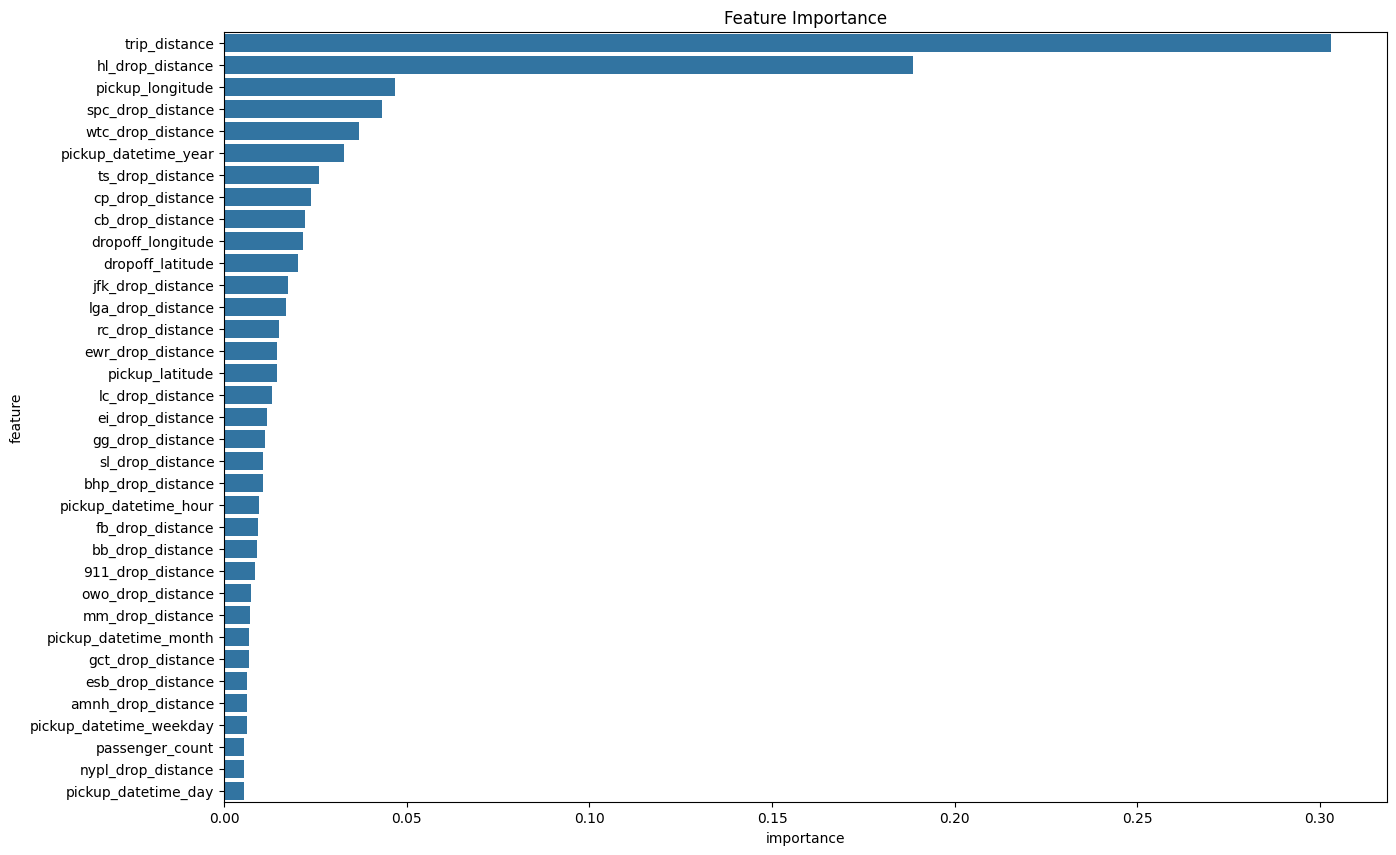

In [100]:
plt.figure(figsize = (15, 10))

sns.barplot(data = importance_df, x = "importance", y = "feature")
plt.title("Feature Importance")
plt.show()